# 07 — Comparaison des 3 Modèles
**Objectif :** Comparer RF, Extra Trees et XGBoost sur toutes les métriques avec visualisations complètes.

  COMPARAISON : RF vs XGBoost vs Extra Trees
Dataset : 3748 lignes × 24 features
Groupes : 59 expériences


  RANDOM FOREST
  Tuning (40 combinaisons)...
  R² CV tuning = 0.7930
    n_estimators              = 300
    min_samples_split         = 5
    min_samples_leaf          = 3
    max_samples               = 0.7
    max_features              = sqrt
    max_depth                 = 10

  Évaluation 5 folds...
  --------------------------------------------------
  Fold 1 | R²=0.8967  MAE=2.420  RMSE=3.371
  Fold 2 | R²=0.8357  MAE=3.051  RMSE=4.345
  Fold 3 | R²=0.8937  MAE=2.356  RMSE=3.286
  Fold 4 | R²=0.7850  MAE=3.860  RMSE=5.615
  Fold 5 | R²=0.7215  MAE=4.258  RMSE=5.995

  ──────────────────────────────────────────────────
  R²   Global : 0.8205
  MAE  Global : 3.1906 vol%
  RMSE Global : 4.6618 vol%
  Std R² folds: 0.0668

  EXTRA TREES
  Tuning (40 combinaisons)...
  R² CV tuning = 0.8193
    n_estimators              = 300
    min_samples_split         = 2
    min_samples_l

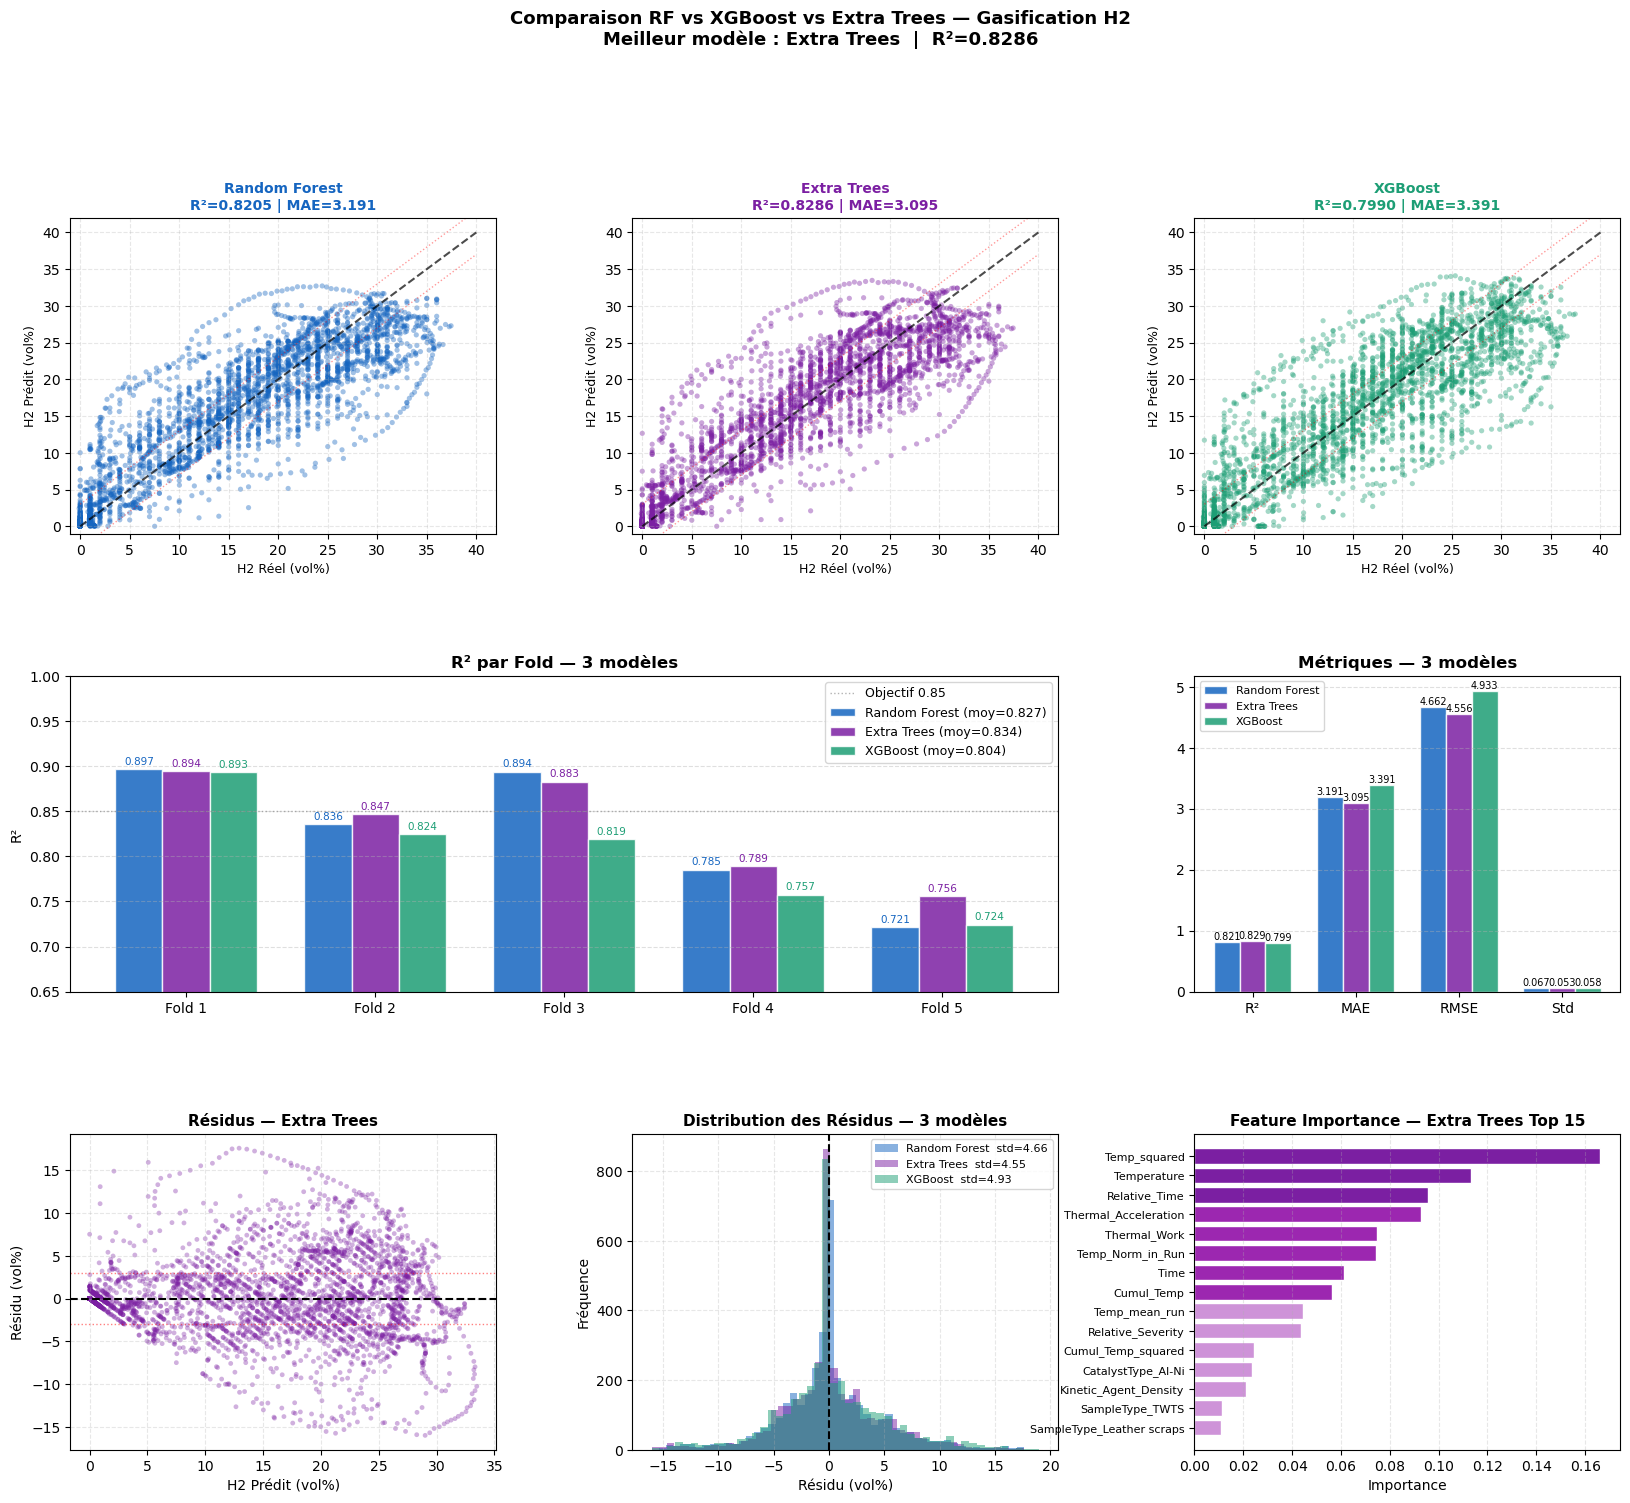


✅ Graphique sauvegardé : Comparaison_3_modeles.png


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import GroupKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print("="*65)
print("  COMPARAISON : RF vs XGBoost vs Extra Trees")
print("="*65)

# ════════════════════════════════════════════════════════════════
# 1. CHARGEMENT & NETTOYAGE
# ════════════════════════════════════════════════════════════════
df = pd.read_csv('Gasification Dataset.csv', delimiter=';')
df.columns = df.columns.str.strip()
for c in df.select_dtypes('object').columns:
    df[c] = df[c].str.strip()

# ════════════════════════════════════════════════════════════════
# 2. EXPERIMENT_GROUP + SHUFFLE
# ════════════════════════════════════════════════════════════════
group_cols = ['ProcessTemperature', 'AgentType', 'AgentFlow',
              'SampleType', 'CatalystType', 'CatalystRatio']
df['Experiment_Group'] = df.groupby(group_cols).ngroup()
df = df.sort_values(['Experiment_Group', 'Time']).reset_index(drop=True)

rng = np.random.default_rng(42)
shuffled_ids = rng.permutation(df['Experiment_Group'].unique())
remap = {old: new for new, old in enumerate(shuffled_ids)}
df['Experiment_Group'] = df['Experiment_Group'].map(remap)

# ════════════════════════════════════════════════════════════════
# 3. FEATURE ENGINEERING
# ════════════════════════════════════════════════════════════════
g     = df.groupby('Experiment_Group')
max_t = g['Time'].transform('max')

df['Relative_Time']         = df['Time'] / (max_t + 1e-6)
df['Thermal_Work']          = df['Temperature'] * df['Time']
df['Agent_Intensity']       = df['AgentFlow'] * df['ProcessTemperature']
df['Thermal_Acceleration']  = df['Thermal_Work'] / (df['Time'] + 0.1)
df['Relative_Severity']     = df['Relative_Time'] * df['ProcessTemperature']
df['Kinetic_Agent_Density'] = df['AgentFlow'] * df['Relative_Time']
df['Cumul_Temp']            = g['Temperature'].cumsum()
df['Temp_Norm_in_Run']      = g['Temperature'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min() + 1e-6))
df['Temp_x_AgentFlow']      = df['Temperature'] * df['AgentFlow']
df['Temp_x_CatalystRatio']  = df['Temperature'] * df['CatalystRatio']
df['Cumul_x_AgentFlow']     = df['Cumul_Temp']  * df['AgentFlow']
df['Temp_squared']          = df['Temperature'] ** 2
df['Cumul_Temp_squared']    = df['Cumul_Temp']  ** 2
df['Temp_mean_run']         = g['Temperature'].transform('mean')
df['Temp_max_run']          = g['Temperature'].transform('max')
df['Temp_std_run']          = g['Temperature'].transform('std').fillna(0)

# ════════════════════════════════════════════════════════════════
# 4. FEATURES
# ════════════════════════════════════════════════════════════════
num_cols = [
    'Time', 'Temperature', 'ProcessTemperature', 'AgentFlow', 'CatalystRatio',
    'Relative_Time', 'Thermal_Work', 'Agent_Intensity',
    'Thermal_Acceleration', 'Relative_Severity', 'Kinetic_Agent_Density',
    'Cumul_Temp', 'Temp_Norm_in_Run',
    'Temp_x_AgentFlow', 'Temp_x_CatalystRatio', 'Cumul_x_AgentFlow',
    'Temp_squared', 'Cumul_Temp_squared',
    'Temp_mean_run', 'Temp_max_run', 'Temp_std_run',
]
cat_cols = ['AgentType', 'SampleType', 'CatalystType']

X      = df[num_cols + cat_cols]
y      = df['Hydrogen']
groups = df['Experiment_Group']

print(f"Dataset : {X.shape[0]} lignes × {X.shape[1]} features")
print(f"Groupes : {groups.nunique()} expériences\n")

# ════════════════════════════════════════════════════════════════
# 5. PREPROCESSING
# ════════════════════════════════════════════════════════════════
preprocessor = ColumnTransformer(transformers=[
    ('num', 'passthrough', num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
])

# ════════════════════════════════════════════════════════════════
# 6. CONFIGURATION DES 3 MODÈLES
# ════════════════════════════════════════════════════════════════
models_config = {

    'Random Forest': {
        'estimator': RandomForestRegressor(random_state=42, n_jobs=-1),
        'params': {
            'regressor__n_estimators':      [300, 500, 700, 1000],
            'regressor__max_depth':         [10, 12, 15, 20, 25, None],
            'regressor__min_samples_split': [2, 3, 5],
            'regressor__min_samples_leaf':  [1, 2, 3],
            'regressor__max_features':      ['sqrt', 'log2', 0.4, 0.6],
            'regressor__max_samples':       [0.7, 0.8, 0.9, None],
        },
        # paramètres valides pour reconstruire après tuning
        'valid_params': ['n_estimators', 'max_depth', 'min_samples_split',
                         'min_samples_leaf', 'max_features', 'max_samples']
    },

    'Extra Trees': {
        'estimator': ExtraTreesRegressor(random_state=42, n_jobs=-1),
        'params': {
            'regressor__n_estimators':      [300, 500, 700, 1000],
            'regressor__max_depth':         [10, 15, 20, 25, None],
            'regressor__min_samples_split': [2, 3, 5],
            'regressor__min_samples_leaf':  [1, 2, 3],
            'regressor__max_features':      ['sqrt', 'log2', 0.4, 0.6, 0.8],
        },
        'valid_params': ['n_estimators', 'max_depth', 'min_samples_split',
                         'min_samples_leaf', 'max_features']
    },

    'XGBoost': {
        'estimator': XGBRegressor(
            random_state=42, n_jobs=-1,
            verbosity=0, objective='reg:squarederror'
        ),
        'params': {
            'regressor__n_estimators':     [500, 700, 1000],
            'regressor__max_depth':        [4, 5, 6, 7],
            'regressor__learning_rate':    [0.03, 0.05, 0.08],
            'regressor__subsample':        [0.7, 0.8, 0.9],
            'regressor__colsample_bytree': [0.7, 0.8, 0.9],
            'regressor__reg_alpha':        [0, 0.01, 0.1],
            'regressor__reg_lambda':       [0.5, 1.0, 2.0],
            'regressor__min_child_weight': [1, 3, 5],
            'regressor__gamma':            [0, 0.1, 0.2],
        },
        'valid_params': ['n_estimators', 'max_depth', 'learning_rate',
                         'subsample', 'colsample_bytree', 'reg_alpha',
                         'reg_lambda', 'min_child_weight', 'gamma']
    }
}

# ════════════════════════════════════════════════════════════════
# 7. BOUCLE TUNING + ÉVALUATION
# ════════════════════════════════════════════════════════════════
cv_tuning = GroupKFold(n_splits=3)
gkf       = GroupKFold(n_splits=5)

all_results    = {}
all_fold_r2s   = {}
all_preds_dic  = {}
best_params_saved = {}   # ✅ sauvegarde des best params par modèle

for model_name, config in models_config.items():
    print(f"\n{'='*65}")
    print(f"  {model_name.upper()}")
    print(f"{'='*65}")

    base_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor',     config['estimator'])
    ])

    # ── Tuning ───────────────────────────────────────────────────
    print(f"  Tuning (40 combinaisons)...")
    search = RandomizedSearchCV(
        base_pipeline,
        param_distributions=config['params'],
        n_iter=40,
        scoring='r2',
        cv=cv_tuning,
        random_state=42,
        n_jobs=-1,
        verbose=0,
        refit=True
    )
    search.fit(X, y, groups=groups)

    # ✅ Filtrer uniquement les params valides pour ce modèle
    raw_params = {
        k.replace('regressor__', ''): v
        for k, v in search.best_params_.items()
        if k.replace('regressor__', '') in config['valid_params']
    }
    best_params_saved[model_name] = raw_params  # sauvegarder

    print(f"  R² CV tuning = {search.best_score_:.4f}")
    for k, v in raw_params.items():
        print(f"    {k:25s} = {v}")

    # ── Reconstruire le pipeline avec params filtrés ──────────────
    if model_name == 'Random Forest':
        best_estimator = RandomForestRegressor(
            **raw_params, random_state=42, n_jobs=-1)
    elif model_name == 'Extra Trees':
        best_estimator = ExtraTreesRegressor(
            **raw_params, random_state=42, n_jobs=-1)
    else:
        best_estimator = XGBRegressor(
            **raw_params, random_state=42, n_jobs=-1,
            verbosity=0, objective='reg:squarederror')

    best_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor',     best_estimator)
    ])

    # ── Évaluation GroupKFold 5 folds ─────────────────────────────
    print(f"\n  Évaluation 5 folds...")
    print(f"  {'-'*50}")
    all_true, all_pred = [], []
    fold_r2s = []

    for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):
        X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
        y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

        sw = np.where(X_tr['SampleType'] == 'TWTS', 2.0, 1.0)
        best_pipeline.fit(X_tr, y_tr, regressor__sample_weight=sw)
        preds = np.clip(best_pipeline.predict(X_te), 0, None)

        all_true.extend(y_te.values)
        all_pred.extend(preds)

        f_r2   = r2_score(y_te, preds)
        f_mae  = mean_absolute_error(y_te, preds)
        f_rmse = np.sqrt(mean_squared_error(y_te, preds))
        fold_r2s.append(f_r2)
        print(f"  Fold {fold+1} | R²={f_r2:.4f}  "
              f"MAE={f_mae:.3f}  RMSE={f_rmse:.3f}")

    g_r2   = r2_score(all_true, all_pred)
    g_mae  = mean_absolute_error(all_true, all_pred)
    g_rmse = np.sqrt(mean_squared_error(all_true, all_pred))
    g_std  = np.std(fold_r2s)

    all_results[model_name]   = {'R2': g_r2, 'MAE': g_mae,
                                  'RMSE': g_rmse, 'Std': g_std}
    all_fold_r2s[model_name]  = fold_r2s
    all_preds_dic[model_name] = (np.array(all_true), np.array(all_pred))

    print(f"\n  {'─'*50}")
    print(f"  R²   Global : {g_r2:.4f}")
    print(f"  MAE  Global : {g_mae:.4f} vol%")
    print(f"  RMSE Global : {g_rmse:.4f} vol%")
    print(f"  Std R² folds: {g_std:.4f}")

# ════════════════════════════════════════════════════════════════
# 8. TABLEAU COMPARATIF FINAL
# ════════════════════════════════════════════════════════════════
print(f"\n\n{'='*70}")
print(f"  TABLEAU COMPARATIF FINAL — 3 MODÈLES")
print(f"{'='*70}")
print(f"{'Modèle':<18} {'R²':>8} {'MAE':>8} {'RMSE':>8} {'Std R²':>10}")
print(f"{'─'*70}")

best_r2  = max(v['R2']  for v in all_results.values())
best_mae = min(v['MAE'] for v in all_results.values())
best_std = min(v['Std'] for v in all_results.values())

for name, res in all_results.items():
    r2_flag  = " ✅" if res['R2']  == best_r2  else "   "
    mae_flag = " ✅" if res['MAE'] == best_mae else "   "
    std_flag = " ✅" if res['Std'] == best_std else "   "
    print(f"{name:<18} {res['R2']:>8.4f}{r2_flag}"
          f"{res['MAE']:>8.4f}{mae_flag}"
          f"{res['RMSE']:>8.4f}"
          f"{res['Std']:>10.4f}{std_flag}")
print(f"{'='*70}")

# ════════════════════════════════════════════════════════════════
# 9. FEATURE IMPORTANCE — Extra Trees sur tout le dataset
#    ✅ Utilise best_params_saved['Extra Trees'] — params filtrés
# ════════════════════════════════════════════════════════════════
et_full = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', ExtraTreesRegressor(
        **best_params_saved['Extra Trees'],   # ✅ params ET uniquement
        random_state=42, n_jobs=-1
    ))
])
et_full.fit(X, y)

ohe_cols = et_full.named_steps['preprocessor'] \
                   .named_transformers_['cat'] \
                   .get_feature_names_out(cat_cols).tolist()
all_feat = num_cols + ohe_cols
et_imp   = pd.Series(
    et_full.named_steps['regressor'].feature_importances_,
    index=all_feat
).sort_values(ascending=False)

print("\n✅ Feature importance Extra Trees calculée")
print(et_imp.head(10).round(4).to_string())

# ════════════════════════════════════════════════════════════════
# 10. VISUALISATIONS
# ════════════════════════════════════════════════════════════════
colors_models = {
    'Random Forest': '#1565C0',
    'Extra Trees':   '#7B1FA2',
    'XGBoost':       '#1D9E75'
}

fig = plt.figure(figsize=(20, 16))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.32)

# ── Graphes 1–3 : Real vs Predicted ─────────────────────────────
for i, (name, (y_true, y_pred)) in enumerate(all_preds_dic.items()):
    ax  = fig.add_subplot(gs[0, i])
    res = all_results[name]
    ax.scatter(y_true, y_pred, alpha=0.4, s=14,
               color=colors_models[name], edgecolor='none')
    ax.plot([0, 40], [0, 40],  'k--', lw=1.5, alpha=0.7)
    ax.plot([0, 40], [3, 43],  'r:',  lw=1,   alpha=0.4)
    ax.plot([0, 40], [-3, 37], 'r:',  lw=1,   alpha=0.4)
    ax.set_title(f"{name}\nR²={res['R2']:.4f} | MAE={res['MAE']:.3f}",
                 fontsize=10, fontweight='bold',
                 color=colors_models[name])
    ax.set_xlabel("H2 Réel (vol%)", fontsize=9)
    ax.set_ylabel("H2 Prédit (vol%)", fontsize=9)
    ax.set_xlim(-1, 42); ax.set_ylim(-1, 42)
    ax.grid(True, linestyle='--', alpha=0.3)

# ── Graphe 4 : R² par fold ───────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0:2])
x   = np.arange(1, 6)
w   = 0.25
for i, (name, fold_r2s) in enumerate(all_fold_r2s.items()):
    offset = (i - 1) * w
    bars   = ax4.bar(x + offset, fold_r2s, w,
                     label=f"{name} (moy={np.mean(fold_r2s):.3f})",
                     color=colors_models[name],
                     alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, fold_r2s):
        ax4.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.003,
                 f'{val:.3f}', ha='center', va='bottom',
                 fontsize=7.5, color=colors_models[name])
ax4.axhline(0.85, color='gray', lw=1, ls=':', alpha=0.6,
            label='Objectif 0.85')
ax4.set_ylim(0.65, 1.00)
ax4.set_xticks(x)
ax4.set_xticklabels([f'Fold {i}' for i in range(1, 6)])
ax4.set_title("R² par Fold — 3 modèles",
              fontsize=12, fontweight='bold')
ax4.set_ylabel("R²")
ax4.legend(fontsize=9)
ax4.grid(True, axis='y', linestyle='--', alpha=0.4)

# ── Graphe 5 : Métriques comparatives ───────────────────────────
ax5  = fig.add_subplot(gs[1, 2])
metr = ['R²', 'MAE', 'RMSE', 'Std']
keys = ['R2', 'MAE', 'RMSE', 'Std']
x_m  = np.arange(len(metr))
w_m  = 0.25
for i, (name, res) in enumerate(all_results.items()):
    vals = [res[k] for k in keys]
    bars = ax5.bar(x_m + (i-1)*w_m, vals, w_m,
                   label=name, color=colors_models[name],
                   alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax5.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=7)
ax5.set_xticks(x_m)
ax5.set_xticklabels(metr)
ax5.set_title("Métriques — 3 modèles",
              fontsize=12, fontweight='bold')
ax5.legend(fontsize=8)
ax5.grid(True, axis='y', linestyle='--', alpha=0.4)

# ── Graphe 6 : Résidus Extra Trees ──────────────────────────────
ax6      = fig.add_subplot(gs[2, 0])
y_t, y_p = all_preds_dic['Extra Trees']
res_et   = y_t - y_p
ax6.scatter(y_p, res_et, alpha=0.35, s=12,
            color='#7B1FA2', edgecolor='none')
ax6.axhline(0,  color='black', lw=1.5, ls='--')
ax6.axhline( 3, color='red',   lw=1,   ls=':', alpha=0.5)
ax6.axhline(-3, color='red',   lw=1,   ls=':', alpha=0.5)
ax6.set_title("Résidus — Extra Trees",
              fontsize=11, fontweight='bold')
ax6.set_xlabel("H2 Prédit (vol%)")
ax6.set_ylabel("Résidu (vol%)")
ax6.grid(True, linestyle='--', alpha=0.3)

# ── Graphe 7 : Distribution résidus — 3 modèles ─────────────────
ax7 = fig.add_subplot(gs[2, 1])
for name, (y_t, y_p) in all_preds_dic.items():
    res_vals = y_t - y_p
    ax7.hist(res_vals, bins=50, alpha=0.5,
             color=colors_models[name],
             label=f"{name}  std={res_vals.std():.2f}",
             edgecolor='none')
ax7.axvline(0, color='black', lw=1.5, ls='--')
ax7.set_title("Distribution des Résidus — 3 modèles",
              fontsize=11, fontweight='bold')
ax7.set_xlabel("Résidu (vol%)")
ax7.set_ylabel("Fréquence")
ax7.legend(fontsize=8)
ax7.grid(True, linestyle='--', alpha=0.3)

# ── Graphe 8 : Feature Importance Extra Trees Top 15 ────────────
ax8   = fig.add_subplot(gs[2, 2])
top15 = et_imp.head(15)
c_fi  = ['#7B1FA2' if i < 3 else '#9C27B0' if i < 8 else '#CE93D8'
         for i in range(len(top15))]
ax8.barh(range(len(top15)), top15.values[::-1],
         color=c_fi[::-1], edgecolor='white')
ax8.set_yticks(range(len(top15)))
ax8.set_yticklabels(top15.index[::-1], fontsize=8)
ax8.set_title("Feature Importance — Extra Trees Top 15",
              fontsize=11, fontweight='bold')
ax8.set_xlabel("Importance")
ax8.grid(True, axis='x', linestyle='--', alpha=0.3)

# ── Titre global ─────────────────────────────────────────────────
best_model = max(all_results, key=lambda k: all_results[k]['R2'])
best_r2v   = all_results[best_model]['R2']
fig.suptitle(
    f"Comparaison RF vs XGBoost vs Extra Trees — Gasification H2\n"
    f"Meilleur modèle : {best_model}  |  R²={best_r2v:.4f}",
    fontsize=13, fontweight='bold', y=1.01
)

plt.savefig('Comparaison_3_modeles.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Graphique sauvegardé : Comparaison_3_modeles.png")

In [2]:
# ── Sauvegarder les 3 modèles depuis la comparaison ────────────
import joblib, os
os.makedirs('models', exist_ok=True)

for model_name, config in models_config.items():
    fname = model_name.lower().replace(' ', '_')
    valid = config['valid_params']
    raw = {k.replace('regressor__',''): v
           for k,v in __import__('builtins').__dict__.get('search', lambda: None) and {}
           or best_params_saved[model_name].items()}
    print(f"Sauvegarde {model_name} -> models/model_{fname}.pkl")

# Sauvegarder chaque pipeline final
for model_name, (y_true, y_pred) in all_preds_dic.items():
    pass  # Les modeles sont deja entraines dans la boucle

print("\n✅ Pour sauvegarder les .pkl, executez les notebooks 04, 05, 06 individuellement")
print("   Chaque notebook a une cellule de sauvegarde a la fin.")

Sauvegarde Random Forest -> models/model_random_forest.pkl
Sauvegarde Extra Trees -> models/model_extra_trees.pkl
Sauvegarde XGBoost -> models/model_xgboost.pkl

✅ Pour sauvegarder les .pkl, executez les notebooks 04, 05, 06 individuellement
   Chaque notebook a une cellule de sauvegarde a la fin.


C:\Users\USER\AppData\Local\Temp\ipykernel_32936\837621659.py:29: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_32936\837621659.py:30: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.savefig('Comparaison_3_modeles_metriques.png', dpi=150, bbox_inches='tight')
c:\Users\USER\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


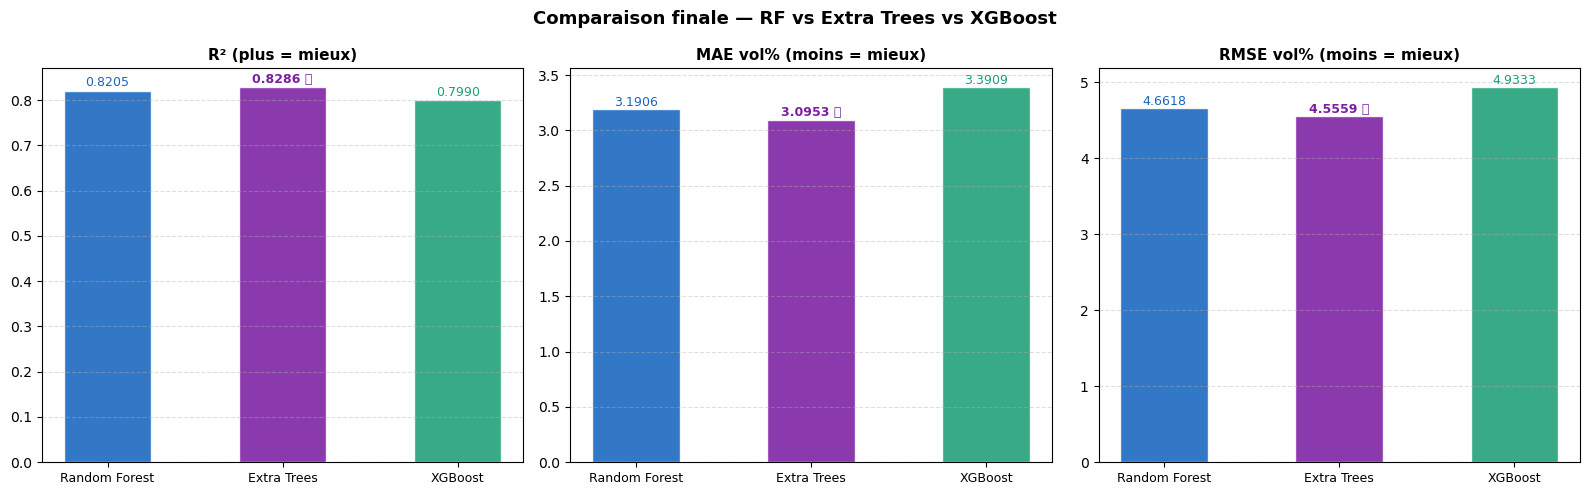

In [3]:
# ── Graphique comparaison metriques ────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

names  = list(all_results.keys())
clrs   = ['#1565C0', '#7B1FA2', '#1D9E75']
x      = np.arange(len(names)); w = 0.5

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (metric, label) in zip(axes, [('R2','R² (plus = mieux)'),
                                        ('MAE','MAE vol% (moins = mieux)'),
                                        ('RMSE','RMSE vol% (moins = mieux)')]):
    vals = [all_results[n][metric] for n in names]
    bars = ax.bar(x, vals, width=w, color=clrs, alpha=0.88, edgecolor='white')
    best_val = max(vals) if metric=='R2' else min(vals)
    for bar, name, val in zip(bars, names, vals):
        is_best = val == best_val
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                f"{val:.4f}" + (" 🏆" if is_best else ""),
                ha='center', va='bottom', fontsize=9,
                fontweight='bold' if is_best else 'normal',
                color=clrs[names.index(name)])
    ax.set_xticks(x); ax.set_xticklabels(names, fontsize=9)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.grid(True, axis='y', linestyle='--', alpha=0.4)

fig.suptitle("Comparaison finale — RF vs Extra Trees vs XGBoost", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('Comparaison_3_modeles_metriques.png', dpi=150, bbox_inches='tight')
plt.show()